<a href="https://colab.research.google.com/github/suryaperumal2004-creator/Cv-colab/blob/main/Object%20flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

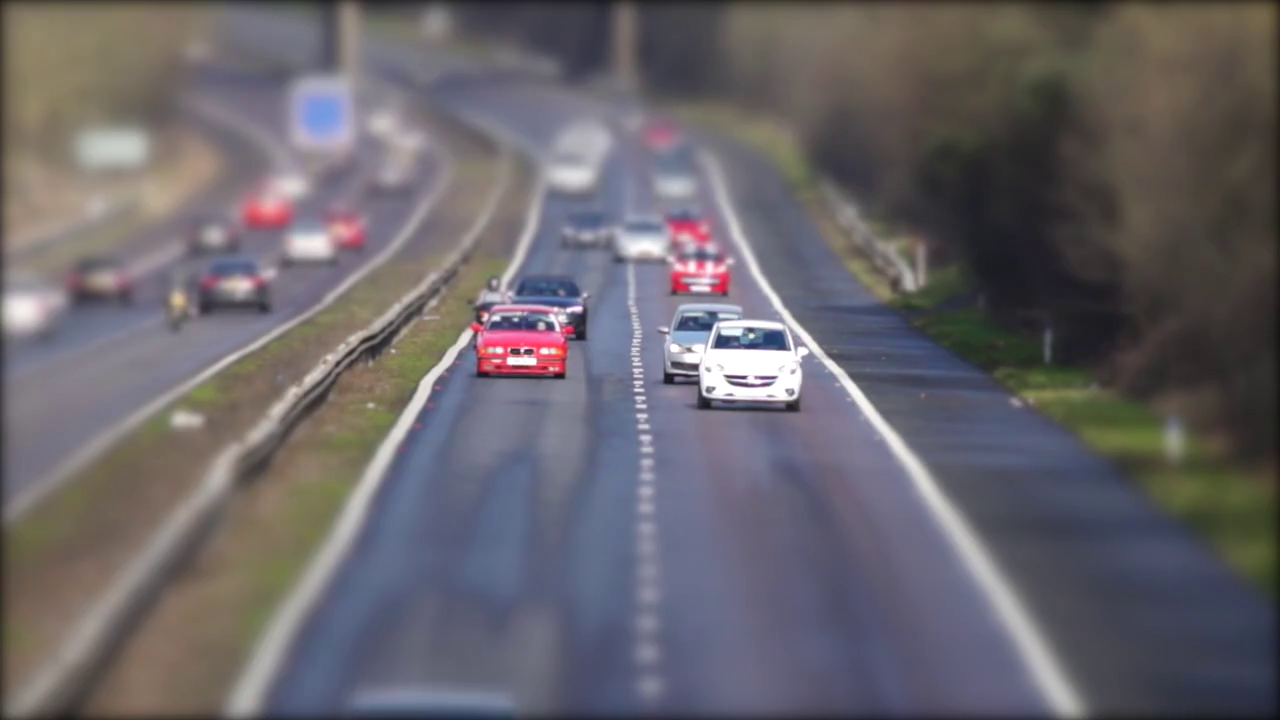

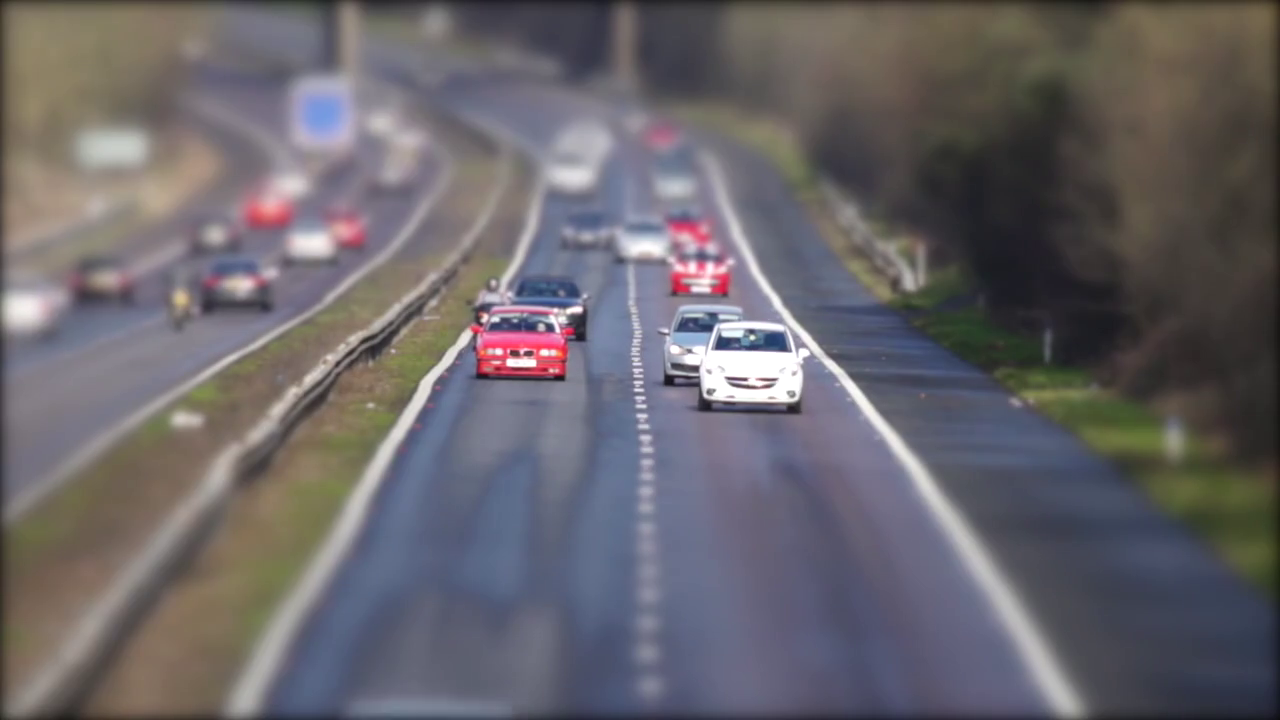

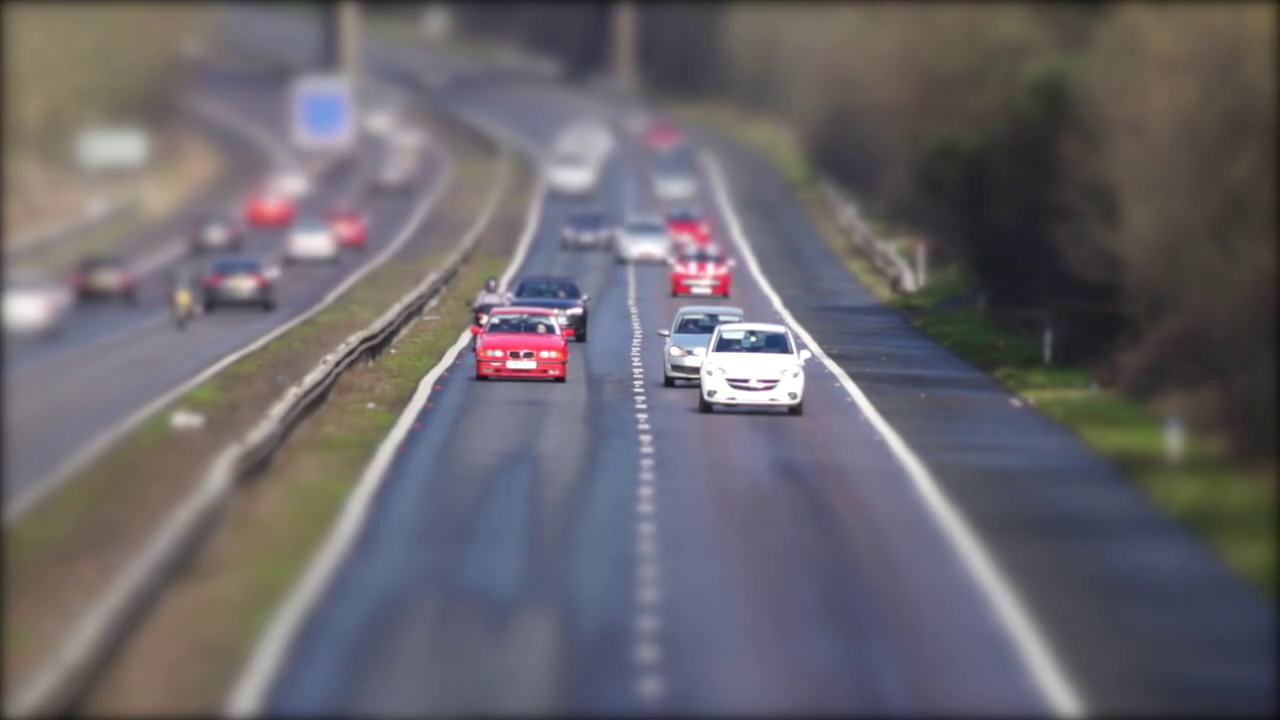

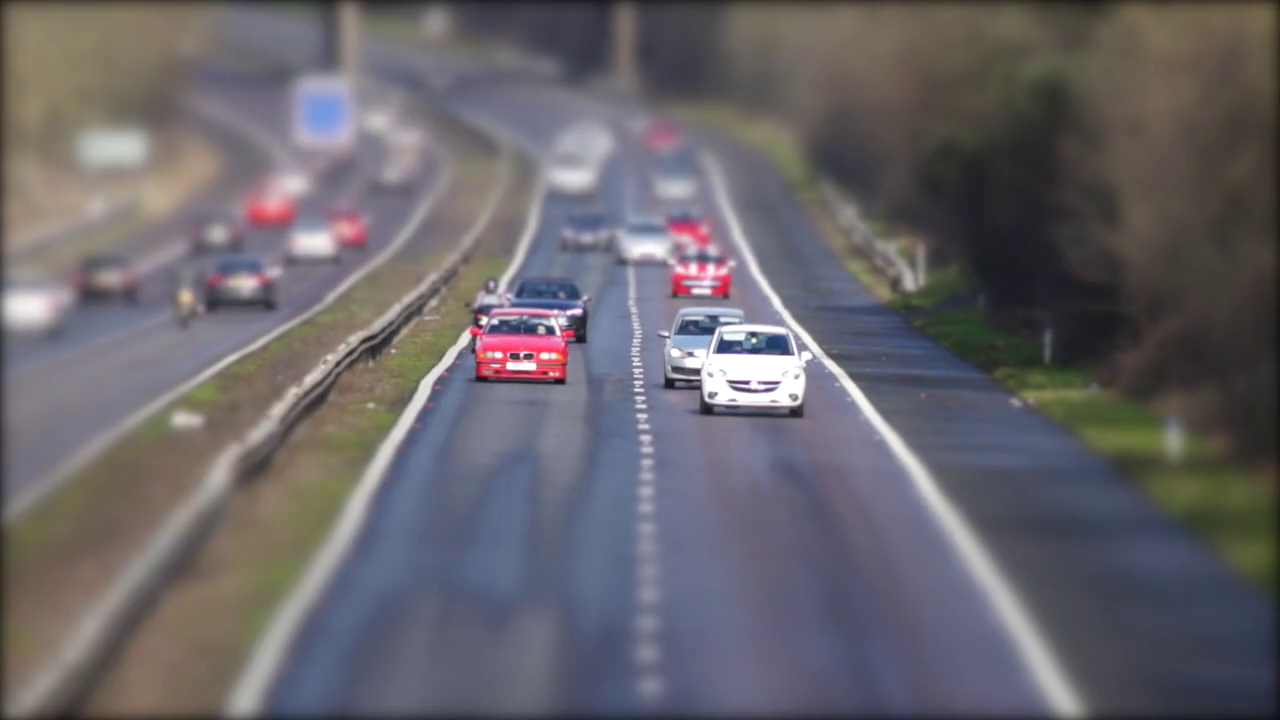

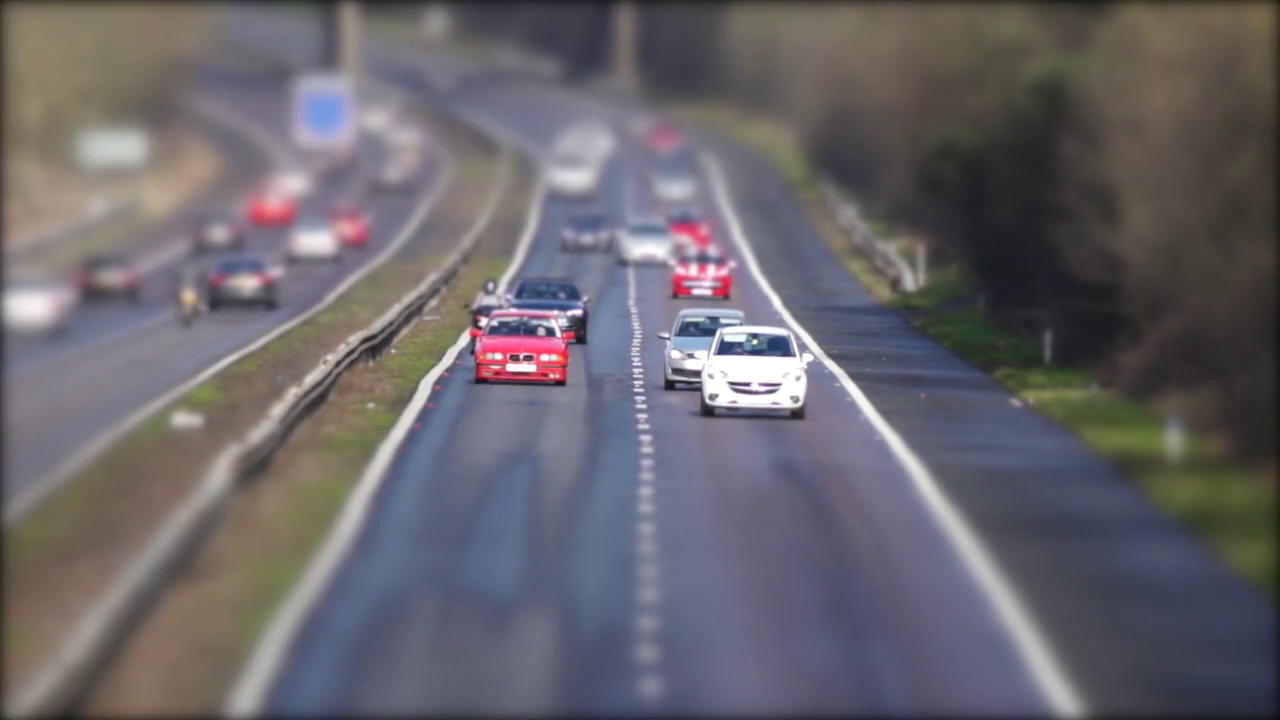

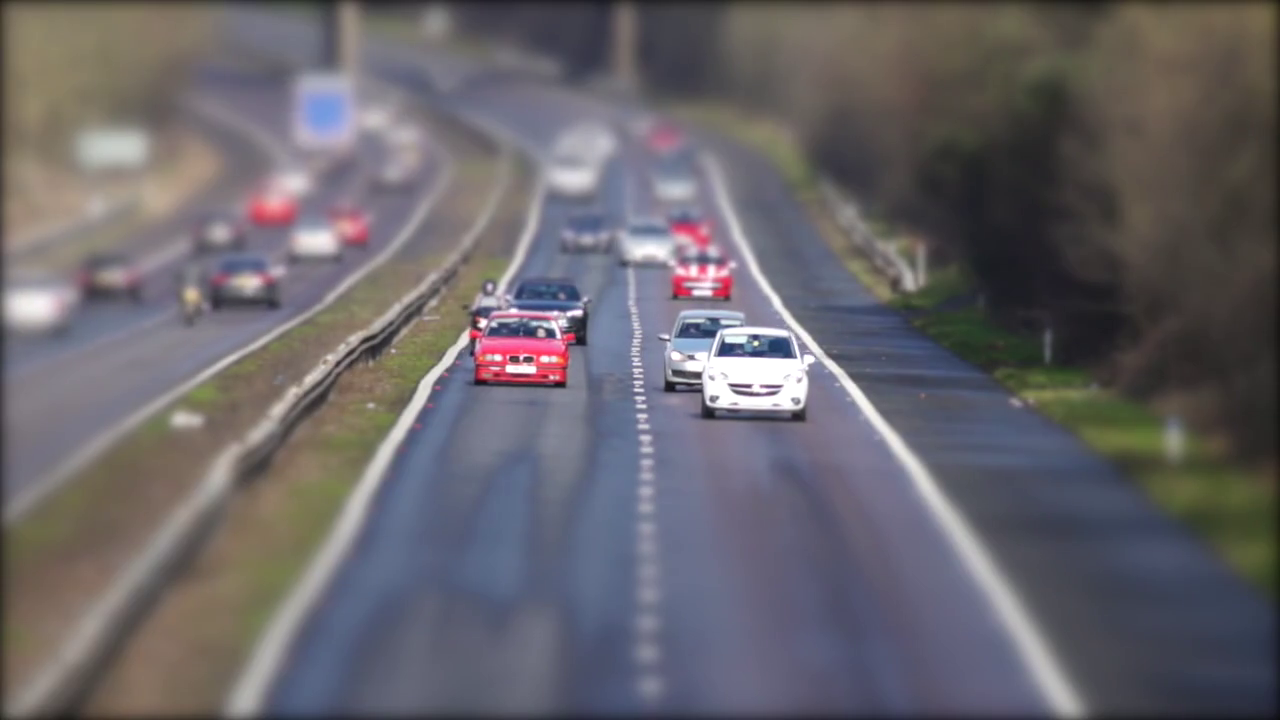

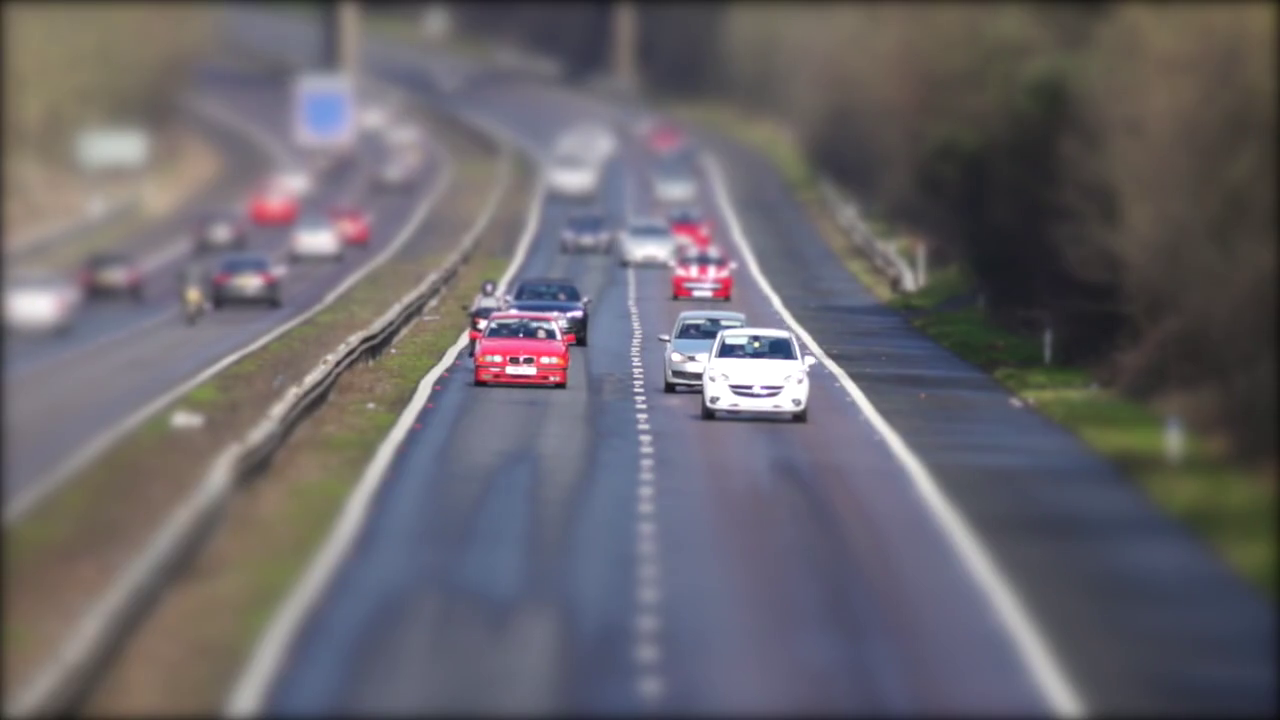

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def calculate_speed(flow, scale_factor, fps):
    if flow.size == 0:
        return 0

    magnitude = np.sqrt(flow[..., 0]**2 + flow[..., 1]**2)
    avg_magnitude = np.mean(magnitude)

    speed_mps = avg_magnitude * scale_factor * fps
    speed_kmph = speed_mps * 3.6

    return speed_kmph


def detect_vehicles(fg_mask):

    contours, _ = cv2.findContours(
        fg_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    vehicles = []

    for contour in contours:

        if cv2.contourArea(contour) > 1000:

            x, y, w, h = cv2.boundingRect(contour)

            if h == 0:
                continue

            aspect_ratio = w / float(h)

            if 0.3 < aspect_ratio < 1.2:
                vehicles.append((x, y, w, h))

    return vehicles


def draw_boxes(frame, vehicles, flow, scale_factor, fps):

    for (x, y, w, h) in vehicles:

        roi_flow = flow[y:y+h, x:x+w]

        speed = calculate_speed(roi_flow, scale_factor, fps)

        cv2.rectangle(frame, (x, y), (x+w, y+h), (0,255,0), 2)

        cv2.putText(
            frame,
            f"{speed:.2f} km/h",
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,255,0),
            2
        )


def main():

    video_path = r"/content/2165-155327596.mp4"

    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error opening video")
        return

    ret, prev_frame = cap.read()

    if not ret:
        print("Cannot read video")
        return

    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)

    background_subtractor = cv2.createBackgroundSubtractorMOG2()

    scale_factor = 0.05
    fps = 30

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            prev_gray,
            gray,
            None,
            0.5,
            3,
            15,
            3,
            5,
            1.2,
            0
        )

        fg_mask = background_subtractor.apply(frame)

        _, fg_mask = cv2.threshold(
            fg_mask,
            200,
            255,
            cv2.THRESH_BINARY
        )

        vehicles = detect_vehicles(fg_mask)

        draw_boxes(frame, vehicles, flow, scale_factor, fps)

        cv2_imshow(frame)

        prev_gray = gray.copy()

        if cv2.waitKey(25) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


if __name__ == "__main__":
    main()

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving 2165-155327596.mp4 to 2165-155327596.mp4
User uploaded file "2165-155327596.mp4" with length 11385951 bytes


After uploading, the file will be available in the current working directory, which is typically `/content/`. You can verify its presence using `!ls /content/`.

# New section